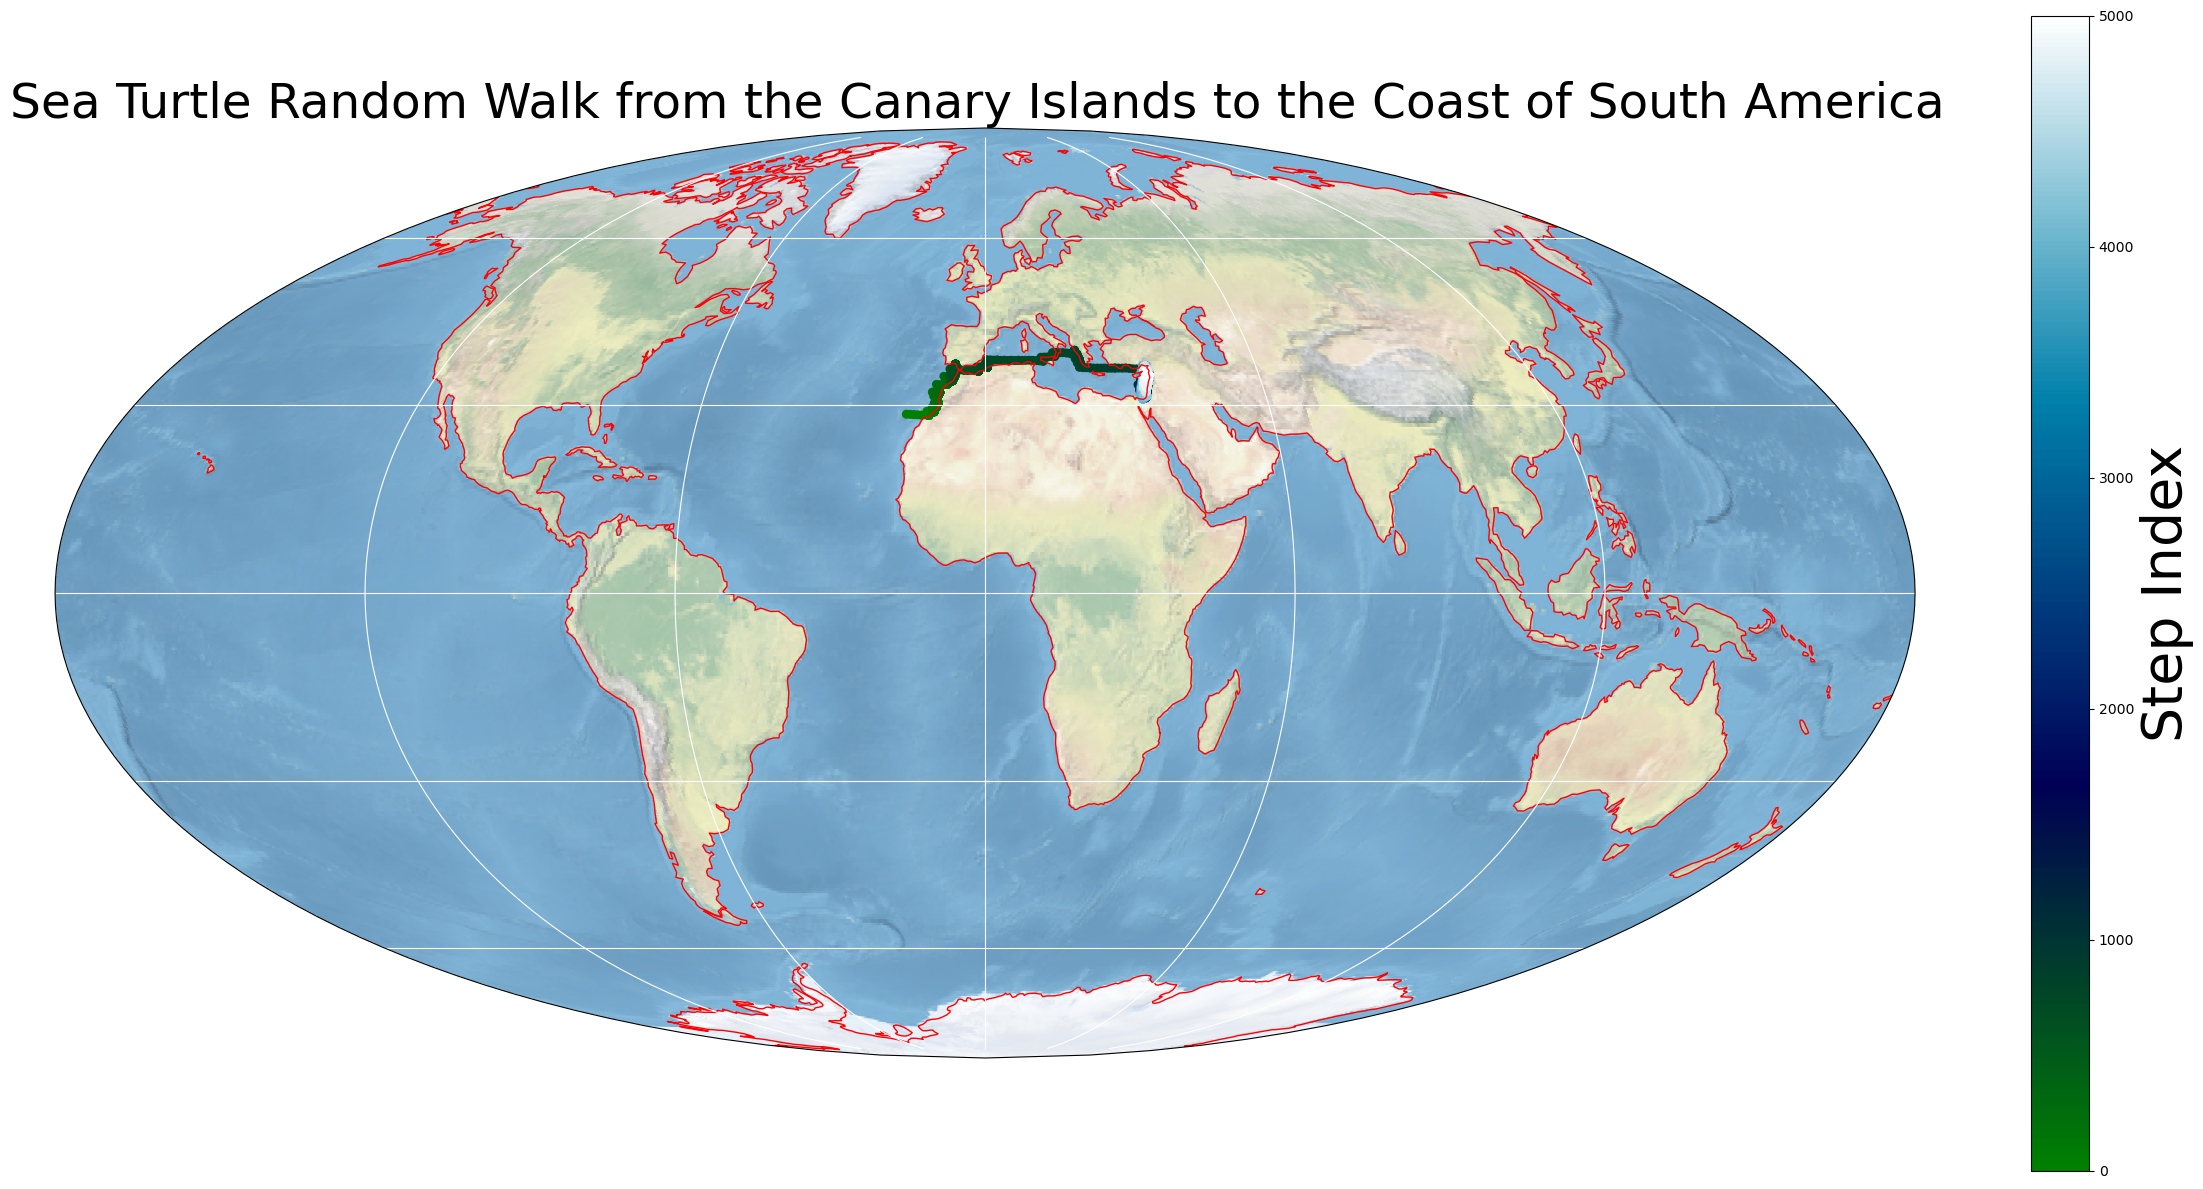

In [8]:
import numpy as np                     
import matplotlib.pyplot as plt             
import random                          
import cartopy.crs as ccrs      
import cartopy.feature as cfeature   
from shapely.geometry import Point   

###load sequence such as ABCAAA
sequences = []                
with open("TurtleData.txt") as f:          
    for line in f:                             
        p = line.strip().split()               #splits string into columns
        if len(p) == 3:                        #row with the only valid sequence
            sequences.append(p[0])             #first column of txt sequence
seq = random.choice(sequences)                 #choose a random sequence


######

#segment is to check whether parts of the plot used in cartopy is land or not
#will be needed since this is a simulation of a sea turtle not a tortoise 
land_polys = list(cfeature.NaturalEarthFeature("physical", "land" , "110m").geometries())                 #list of polygons for construct land shape from shapely package
        
def is_land(lon, lat):      #returns a boolean value of TRUE or FALSE if vlaues of (lon, lat) are on land
    pt = Point(lon, lat)                       #makes lon and lat into a POINT object from shapely
    for poly in land_polys:                    #iterates for every land object
        if poly.contains(pt):                  #checks to see if object is considered land
            return True                        #if it is within the POINT object then it returns true
    return False                               #if it is not within the POINT object then its false

######
#turtle classes and editted code from a previous class assignment
class Turtle:
    def __init__(self):
        self.reset( )        #initializes turtle

    def paddle(self, angle, distance = 1.0):
        theta = np.deg2rad( angle)              #convert angles to radians
        dx = distance * np.cos(theta)    
        dy =  distance * np.sin(theta)    
        self.pos += np.array( [dx,  dy])         #update turtle's position from x and y movements
        self.traj.append(self.pos.copy() )      #stored into a trajectory to create a time series which is needed to revert to preious locations of the turtle and plotting

    def reset(self):
        self.pos = np.zeros(2)                #start at origin in local coordinates
        self.traj= [self.pos.copy( )]         #begin at origin

class PaddleTurtle(Turtle):
    def swim_step(self, letter):
        directions = {'A' : 0, 'B' : 120,  'C': 240}    #paddle directions, if A then the turtle will continue going straight, B then turtle will rotate 120 degrees, C rotate 240
        base = directions.get(letter, 0)          
        noisy =base +random.uniform( -5, 5)   #paddle noise
        self.paddle(noisy) 



######
#Stay_in_ocien
def stay_in_ocean(turtle, letter, lon, lat, scale, tgt_lon, tgt_lat):
    directions = {'A' : 0, 'B' : 120,  'C': 240}    #paddle directions, if A then the turtle will continue going straight, B then turtle will rotate 120 degrees, C rotate 240
    base = directions.get(letter, 0)                # base paddle angle for cycle letter

    for i in range(20):                        # allow up to 20 land-avoidance retries
        angle = base + random.uniform(-5, 5)   
        theta = np.deg2rad( angle)       
        before = turtle.pos.copy()             #copy turtle position
        turtle.paddle(angle)                   #turtle moves
        dx, dy = turtle.pos - before   

        new_lon = lon + dx * scale      #shift on the longitude axis (north/south)
        new_lat = lat + dy * scale      #shift on the latitude axis (east/west)

        goal = np.arctan2(tgt_lat - lat,tgt_lon - lon)       #target location which is argentina
        new_lon += 0.02 * np.cos(goal)      
        new_lat += 0.02 * np.sin(goal)   

        if not is_land(new_lon, new_lat):      #if is water
            return new_lon,  new_lat            #accept movement
        
        turtle.pos = before.copy()        
        turtle.traj[-1] = before.copy()     
    return lon, lat                    #if doesnt work do this



#migration loop from origins to destination
#the final stretch this is wher ethe turtle goes
START_LON, START_LAT = -16.5, 28.5             #Canary Island
TARGET_LON, TARGET_LAT = -60, -35              #Argentina

scale = .8                                    #the distance of each step, you dont want it to be too large (a values llike 2 will cause the object to bump into land too frequentluy)
paddles = 5000                                   #how many paddles
letters = seq                                  #the sequence of the ABC 
position = PaddleTurtle()                            #create a local coordinate turtle

lon, lat = START_LON, START_LAT                  
lons = [lon]                #store into list
lats = [lat]               #into list

for i in range(paddles):                          # iterate through all migration steps
    letter = chr(random.randint(65, 90))        #go through letters
    lon, lat = stay_in_ocean(position, letter, lon, lat, scale, TARGET_LON, TARGET_LAT) #update paddle location
    lons.append(lon)                           #store updated lon for later plotting
    lats.append(lat)                           # store updated lat for later plotting


###plotting
ax = plt.figure(figsize= (30, 15)).add_subplot(1 , 1, 1, projection = ccrs.Mollweide())  # global map projection

ax.stock_img()  
ax.coastlines(resolution = '110m', color = 'red')  #mkaes the coastline red, for visuals
ax.gridlines(color = 'white')                                 #draw lat/lon grid
path = ax.scatter(lons, lats, c = np.arange(len(lons)), cmap="ocean" ,s = 30, transform=ccrs.PlateCarree())      #path migration
bar = plt.colorbar(path)
bar.set_label("Step Index", fontsize = 40)

ax.set_title("Sea Turtle Random Walk from the Canary Islands to the Coast of South America ", fontsize = 35)     
plt.show() 


#finish commenting sections, 